<a href="https://colab.research.google.com/github/OlhaZahrebelna/Intelligent-Support-Ticket-Router-using-NLP/blob/main/02_Preprocessing_and_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing and Baseline Models

This notebook builds a traditional NLP baseline for support-ticket routing.
The main workflow is:

1. Load and inspect the cleaned ticket dataset.
2. Split the data into train and test sets using stratification.
3. Apply text preprocessing inside a scikit-learn compatible transformer.
4. Convert text into TF-IDF features.
5. Train baseline classifiers: Logistic Regression and Linear SVM.
6. Evaluate models using classification reports, Macro F1, and error analysis.

## Import Libraries

In [1]:
# Standard Library
import re
import string

# Third-party Libraries
import pandas as pd
import spacy
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Saving a Model
!pip install joblib
import joblib

# Scikit-learn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
)
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


## Load the Dataset

In [2]:
df = pd.read_csv("customer_support_tickets_cleaned.csv")

## Explore the Dataset

In [3]:
df.head()

,text,subject,body,queue,priority,type,language
0,"Account Disruption Dear Customer Support Team,...",Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,Incident,en
1,Query About Smart Home System Integration Feat...,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,Request,en
2,Inquiry Regarding Invoice Details Dear Custome...,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,Request,en
3,Question About Marketing Agency Software Compa...,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,Problem,en
4,"Feature Query Dear Customer Support,\n\nI hope...",Feature Query,"Dear Customer Support,\n\nI hope this message ...",Technical Support,high,Request,en


In [4]:
df.shape

(28261, 7)

#### Check missing values

In [5]:
df.isnull().sum()

,0
text,0
subject,3639
body,1
queue,0
priority,0
type,0
language,0


## Define Features and Target

`X` contains the ticket text used as model input.
`y` contains the queue labels that the model needs to predict.

In [6]:
X = df['text']
y = df['queue']

## Train-Test Split

A stratified split is used to preserve the original class distribution in both train and test sets.
This is important because support-ticket datasets often contain imbalanced classes.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Text Preprocessing

The custom `TextPreprocessor` class is compatible with scikit-learn pipelines.
This is important because preprocessing must be applied only inside the training pipeline, avoiding data leakage.

The class performs:

- lowercasing;
- URL removal;
- email removal;
- HTML tag removal;
- whitespace normalization;
- lemmatization with spaCy;
- stopword removal;
- removal of numbers and non-alphabetic tokens;
- removal of very short tokens.

In [8]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])


class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, min_token_len=2):
        self.min_token_len = min_token_len

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [self.preprocess(text) for text in X]

    def preprocess(self, text):
        if not isinstance(text, str):
            text = ""

        text = text.lower()

        # remove urls
        text = re.sub(r"http\S+|www\S+", " ", text)

        # remove emails
        text = re.sub(r"\S+@\S+", " ", text)

        # remove html tags
        text = re.sub(r"<.*?>", " ", text)

        # normalize spaces before spaCy
        text = re.sub(r"\s+", " ", text).strip()

        doc = nlp(text)

        tokens = [
            token.lemma_
            for token in doc
            if token.is_alpha
            and not token.is_stop
            and not token.like_num
            and len(token.lemma_) >= self.min_token_len
        ]

        return " ".join(tokens)

### Preprocessing Rationale

This preprocessing design is suitable for a traditional TF-IDF + linear model baseline.
It reduces vocabulary noise while preserving meaningful lexical information.

Important note: the model still depends on words and short phrases. Therefore, the preprocessing should not be too aggressive.
For example, removing all domain-specific words or product names could hurt performance because these tokens may help identify the correct queue.

## TF-IDF

TF-IDF converts cleaned text into sparse numerical vectors.
Terms that are frequent in a specific ticket but not too common across all tickets receive higher weights.

This representation is a strong baseline for classical machine learning models in text classification.

## Baseline Model: Logistic Regression

Logistic Regression is a good first baseline for text classification because it is fast, interpretable, and works well with sparse TF-IDF features.

In [9]:
logreg_pipeline = Pipeline([
    ("preprocessing", TextPreprocessor()),
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [10]:
logreg_pipeline.fit(X_train, y_train)

y_pred_log = logreg_pipeline.predict(X_test)

## Logistic Regression Metrics

Macro F1 is especially important here because the dataset is likely imbalanced.
It gives equal weight to each class, so poor performance on minority classes is not hidden by strong performance on large classes.

In [11]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

print("Macro F1:",
      f1_score(y_test, y_pred_log, average="macro"))

Logistic Regression
                                 precision    recall  f1-score   support

           Billing and Payments       0.85      0.71      0.77       579
               Customer Service       0.40      0.39      0.39       854
                General Inquiry       1.00      0.02      0.05        81
                Human Resources       0.87      0.18      0.30       111
                     IT Support       0.44      0.24      0.31       667
                Product Support       0.41      0.41      0.41      1061
          Returns and Exchanges       0.69      0.18      0.29       280
            Sales and Pre-Sales       0.67      0.17      0.27       169
Service Outages and Maintenance       0.81      0.50      0.62       221
              Technical Support       0.46      0.74      0.57      1630

                       accuracy                           0.49      5653
                      macro avg       0.66      0.35      0.40      5653
                   weighted a

## Improved Model 1: Logistic Regression with Optimized TF-IDF Features

This version improves the feature representation by using:

- `ngram_range=(1, 2)`: includes unigrams and bigrams, useful for phrases like `password reset` or `billing issue`;
- `min_df=2`: removes very rare terms that may be noise;
- `max_df=0.95`: removes extremely common terms;
- `sublinear_tf=True`: dampens the effect of repeated words.


In [12]:
logreg_pipeline2 = Pipeline([
    ("preprocessing", TextPreprocessor()),
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [13]:
logreg_pipeline2.fit(X_train, y_train)

y_pred_log2 = logreg_pipeline2.predict(X_test)

## Metrics for Logistic Regression with Improved TF-IDF

This comparison shows whether better feature engineering improves the baseline model.

In [14]:
print("Logistic Regression with balanced class weights")
print(classification_report(y_test, y_pred_log2))

print("Macro F1:",
      f1_score(y_test, y_pred_log2, average="macro"))

Logistic Regression with balanced class weights
                                 precision    recall  f1-score   support

           Billing and Payments       0.94      0.76      0.84       579
               Customer Service       0.57      0.55      0.56       854
                General Inquiry       1.00      0.09      0.16        81
                Human Resources       1.00      0.18      0.31       111
                     IT Support       0.72      0.39      0.50       667
                Product Support       0.57      0.59      0.58      1061
          Returns and Exchanges       1.00      0.26      0.41       280
            Sales and Pre-Sales       0.88      0.22      0.36       169
Service Outages and Maintenance       0.90      0.52      0.66       221
              Technical Support       0.53      0.86      0.66      1630

                       accuracy                           0.61      5653
                      macro avg       0.81      0.44      0.50      5653
 

Improving the preprocessing pipeline and tuning the TF-IDF representation significantly enhanced the baseline Logistic Regression model. The Macro F1 score increased from 0.40 to 0.50, indicating better performance across all classes, particularly the minority ones. Although some classes remain challenging to distinguish, the improved preprocessing and feature engineering provide a stronger and more reliable baseline for the ticket routing task.

## Baseline Model 2: Linear SVM

Linear SVM is often very strong for sparse high-dimensional text features.
It tries to find a separating hyperplane with a large margin between classes.


In [15]:
svm_pipeline = Pipeline([
    ("preprocessing", TextPreprocessor()),
    ("tfidf", TfidfVectorizer()),
    ("classifier", LinearSVC())
])

In [16]:
svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

## Linear SVM Metrics

These metrics are compared with Logistic Regression to identify the stronger baseline model.

In [17]:
print("Linear SVM")
print(classification_report(y_test, y_pred_svm))

print("Macro F1:",
      f1_score(y_test, y_pred_svm, average="macro"))

Linear SVM
                                 precision    recall  f1-score   support

           Billing and Payments       0.82      0.78      0.80       579
               Customer Service       0.45      0.41      0.43       854
                General Inquiry       0.74      0.25      0.37        81
                Human Resources       0.72      0.38      0.50       111
                     IT Support       0.44      0.32      0.37       667
                Product Support       0.43      0.44      0.44      1061
          Returns and Exchanges       0.64      0.34      0.44       280
            Sales and Pre-Sales       0.62      0.33      0.43       169
Service Outages and Maintenance       0.71      0.63      0.67       221
              Technical Support       0.51      0.70      0.59      1630

                       accuracy                           0.53      5653
                      macro avg       0.61      0.46      0.50      5653
                   weighted avg       

## Improved Model 2: Linear SVM with Optimized TF-IDF Features and Balanced Class Weights

This model combines stronger TF-IDF features with `class_weight="balanced"`.
Balanced class weights increase the penalty for mistakes on minority classes, which can improve Macro F1.

In [18]:
svm_pipelineB = Pipeline([
    ("preprocessing", TextPreprocessor()),
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True)),
    ("classifier", LinearSVC(class_weight='balanced', C=0.5))
])

In [19]:
svm_pipelineB.fit(X_train, y_train)
y_pred_svmB = svm_pipelineB.predict(X_test)

## Metrics for Linear SVM with Optimized TF-IDF Features and Balanced Class Weights

This is the strongest baseline candidate in the notebook.

In [20]:
print("Linear SVM")
print(classification_report(y_test, y_pred_svmB))

print("Macro F1:",
      f1_score(y_test, y_pred_svmB, average="macro"))

Linear SVM
                                 precision    recall  f1-score   support

           Billing and Payments       0.89      0.88      0.88       579
               Customer Service       0.70      0.69      0.70       854
                General Inquiry       0.66      0.75      0.70        81
                Human Resources       0.80      0.81      0.81       111
                     IT Support       0.67      0.69      0.68       667
                Product Support       0.72      0.68      0.70      1061
          Returns and Exchanges       0.71      0.74      0.72       280
            Sales and Pre-Sales       0.60      0.71      0.65       169
Service Outages and Maintenance       0.73      0.86      0.79       221
              Technical Support       0.76      0.74      0.75      1630

                       accuracy                           0.74      5653
                      macro avg       0.72      0.76      0.74      5653
                   weighted avg       

The improved Linear SVM achieved the best overall performance among all baseline models. The Macro F1 score increased substantially from 0.50 to 0.74, demonstrating a much better balance between precision and recall across all ticket categories, including minority classes. These results show that the enhanced preprocessing pipeline and optimized TF-IDF representation significantly improved the model's ability to distinguish between support ticket categories. Therefore, the improved Linear SVM was selected as the strongest baseline model for the intelligent support ticket routing task.

## Model Comparison Summary

The Linear Support Vector Machine outperformed Logistic Regression on the customer request routing task.
It achieved a higher Macro F1 score, indicating a better balance between precision and recall across departments.

The improvement is especially important for minority classes, where accuracy alone would be misleading.
However, the model still struggles with underrepresented or semantically overlapping classes.
This suggests that both class imbalance and category similarity remain key limitations.

## Error Analysis


Error analysis helps understand *why* the model fails, not only how often it fails.
The goal is to identify:

- which classes are confused most often;
- whether errors happen between semantically similar queues;
- whether minority classes are systematically misclassified;
- examples of tickets that may be ambiguous or mislabeled.

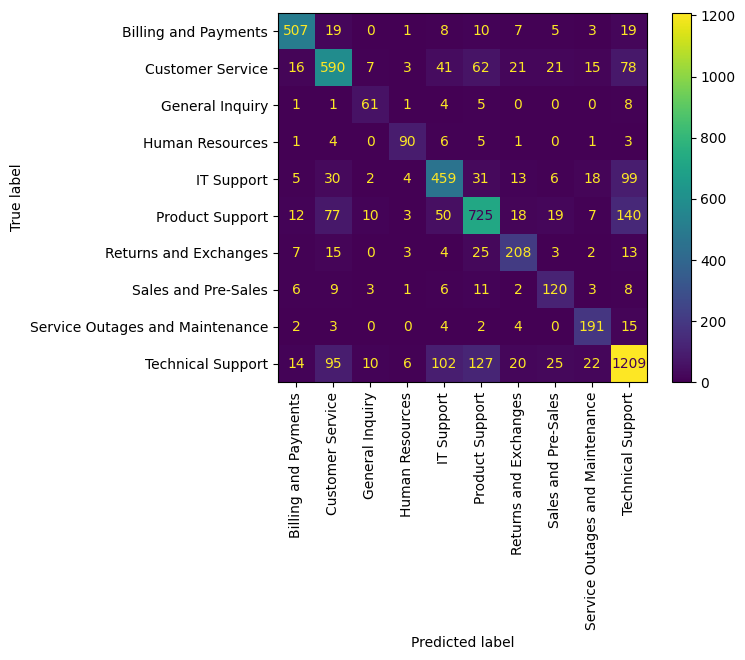

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svmB,
    xticks_rotation=90
)

The confusion matrix shows that the model correctly classifies most tickets, while some queue pairs are confused more frequently than others. The largest off-diagonal values indicate systematic misclassification between semantically similar categories. These errors may be caused by overlapping vocabulary between support queues, short or ambiguous ticket descriptions, class imbalance, or potential label noise in the dataset. Further error analysis of individual misclassified examples would help identify the dominant source of these errors.

## Create a dataframe that stores the original text, true label, and predicted label


In [22]:
error_df = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": y_pred_svmB
})

## Show first examples of model mistakes

In [23]:
errors = error_df[error_df["true"] != error_df["pred"]]

errors.head(10)

,text,true,pred
15938,Security Protocols Following a Data Breach in ...,Returns and Exchanges,Customer Service
10644,Strategies for Brand Growth in the Digital Spa...,Customer Service,Technical Support
3021,Digital Strategies of Marketing Agency Showing...,Technical Support,Customer Service
23378,Problem with Marketing Engagement The marketin...,Product Support,Customer Service
13223,Problem with Microsoft Teams Freezing During D...,Technical Support,IT Support
23016,Request for Compatibility Update with MATLAB R...,Technical Support,Returns and Exchanges
6099,Concerns with Data Analytics The data analytic...,Technical Support,Returns and Exchanges
22726,Report of Incident: Medical Data Encryption Fa...,IT Support,Technical Support
19721,Trouble Logging In Post Update Dear Customer S...,Technical Support,IT Support
1909,Assistance with Software and Hardware Integrat...,Technical Support,IT Support


The error analysis shows that most misclassified tickets belong to semantically similar support categories. This indicates that overlapping vocabulary and limited contextual information make these classes difficult to distinguish. Inspecting individual errors provides valuable insights for improving future versions of the model.

In [24]:
print(f"Total test samples: {len(error_df)}")
print(f"Errors: {len(errors)}")
print(f"Error rate: {len(errors) / len(error_df):.2%}")

Total test samples: 5653
Errors: 1493
Error rate: 26.41%


### Most Frequent Misclassification Pairs

The table below shows where the model makes mistakes most often.
This is more informative than looking only at the total number of errors.


In [25]:
errors_by_pair = (
    errors
    .groupby(["true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

errors_by_pair.head(10)

,true,pred,count
47,Product Support,Technical Support,140
76,Technical Support,Product Support,127
75,Technical Support,IT Support,102
38,IT Support,Technical Support,99
72,Technical Support,Customer Service,95
16,Customer Service,Technical Support,78
40,Product Support,Customer Service,77
12,Customer Service,Product Support,62
43,Product Support,IT Support,50
11,Customer Service,IT Support,41


## Model saving

In [26]:
joblib.dump(svm_pipelineB, "svm_pipeline.joblib")

['svm_pipeline.joblib']

#Final Conclusion

In this notebook, several baseline models for support ticket classification were developed and evaluated using a consistent preprocessing and feature engineering pipeline. Since the dataset is imbalanced, Macro F1 was selected as the primary evaluation metric because it gives equal importance to all classes.

The experiments demonstrated that improving the preprocessing pipeline and optimizing the TF-IDF representation substantially increased classification performance. Among the evaluated models, the improved Linear SVM achieved the best results, reaching a Macro F1 score of 0.74, making it the strongest baseline for the ticket routing task.

Error analysis showed that most misclassifications occurred between semantically related categories, particularly Technical Support, IT Support, and Product Support, indicating that these queues share similar vocabulary and ticket descriptions. Despite these challenges, the model achieved balanced performance across most classes and provides a strong foundation for further improvements.

Future work may focus on hyperparameter optimization, contextual text representations (e.g., BERT or Sentence Transformers), and advanced techniques for handling class imbalance to further improve classification accuracy across similar support categories.